In [3]:
import xarray as xr

ds = xr.open_dataset(r"C:\Users\polinae\Documents\sog-hfradar\data\processed\sog_hfradar_2026.nc")

# Just print the structure — no data loaded yet
print(ds)

<xarray.Dataset> Size: 320MB
Dimensions:     (grid_point: 2532, time: 3164)
Coordinates:
  * time        (time) datetime64[ns] 25kB 2026-01-01 ... 2026-05-12T18:59:59...
Dimensions without coordinates: grid_point
Data variables:
    lon         (grid_point) float32 10kB ...
    lat         (grid_point) float32 10kB ...
    U           (time, grid_point) float32 32MB ...
    V           (time, grid_point) float32 32MB ...
    U_raw       (time, grid_point) float32 32MB ...
    V_raw       (time, grid_point) float32 32MB ...
    U_err       (time, grid_point) float32 32MB ...
    V_err       (time, grid_point) float32 32MB ...
    qc_overall  (time, grid_point) float32 32MB ...
    qc_speed    (time, grid_point) float32 32MB ...
    qc_gdop     (time, grid_point) float32 32MB ...
    n_radials   (time, grid_point) float32 32MB ...
Attributes: (12/14)
    title:                Strait of Georgia CODAR HF Radar Surface Currents
    institution:          Ocean Networks Canada
    source:    

In [4]:
import numpy as np

# Apply QC mask — keep only good data
ds_good = ds.where(ds.qc_overall == 1)

# % of good data
good_pct = (ds.qc_overall == 1).mean().values * 100
print(f"Good data (qc=1): {good_pct:.1f}%")

# Speed
speed = np.sqrt(ds_good.U**2 + ds_good.V**2)
print(f"Max speed:  {float(speed.max()):.1f} cm/s")
print(f"Mean speed: {float(speed.mean()):.1f} cm/s")

# Time coverage
print(f"\nStart: {str(ds.time.values[0])[:16]}")
print(f"End:   {str(ds.time.values[-1])[:16]}")
print(f"N timesteps: {ds.dims['time']}")
print(f"N grid points: {ds.dims['grid_point']}")

Good data (qc=1): 36.8%
Max speed:  218.5 cm/s
Mean speed: 29.7 cm/s

Start: 2026-01-01T00:00
End:   2026-05-12T18:59
N timesteps: 3164
N grid points: 2532


C:\Users\polinae\AppData\Local\Temp\ipykernel_39332\2479448841.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"N timesteps: {ds.dims['time']}")
C:\Users\polinae\AppData\Local\Temp\ipykernel_39332\2479448841.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"N grid points: {ds.dims['grid_point']}")


In [3]:
from onc import ONC

onc = ONC("0023417b-fa9d-4d1e-a670-f24808c71918")

# Find the CODAR location
results = onc.getLocations({"locationName": "Strait of Georgia"})
for r in results:
    print(r['locationName'], '|', r['locationCode'])

Strait of Georgia VENUS Instrument Platform | SCVIP
Strait of Georgia East VENUS Instrument Platform | SEVIP
Strait of Georgia Central Node Primary Board | SGC.ND1
Strait of Georgia Central Node Secondary Board | SGC.ND2
Strait of Georgia East Node Primary Board | SGE.ND1
Strait of Georgia East Node Secondary Board | SGE.ND2
Strait of Georgia CODAR System | SOGCS


In [7]:
# Request a NetCDF download for January 2026
result = onc.orderDataProduct({
    "locationCode": "SOGCS",
    "deviceCategoryCode": "OCEANOGRAPHICRADAR",
    "dataProductCode": "CODARQCSC",
    "extension": "nc",
    "dateFrom": "2026-01-01T00:00:00.000Z",
    "dateTo": "2026-01-31T23:59:59.000Z",
}, includeMetadataFile=False)

print(result)

{'dataProductCode': 'CODARQCSC',
 'dateFrom': '2026-01-01T00:00:00.000Z',
 'dateTo': '2026-01-31T23:59:59.000Z',
 'deviceCategoryCode': 'OCEANOGRAPHICRADAR',
 'extension': 'nc',
 'locationCode': 'SOGCS'},
there are several warning messages:
* No value was given for the required parameter dpo_IncludeRadials the default value 1 will be used. For additional information about this parameter see https://wiki.oceannetworks.ca/pages/viewpage.action?pageId=81887426



Request Id: 37272962
Estimated File Size: 14 MB
Estimated Processing Time: 25 min
To cancel the running data product, run 'onc.cancelDataProduct(37272962)'


   Running
   Running... creation date on CODAR grid file STRAITOFGEORGIAARRAY_20160510T194413.000Z-CODAR.grd is 10-May-2016 19:44:13, in deployment 1 of 1.
   Running... working on time step 6 of 744, 01-Jan-2026 05:00:00, in deployment 1 of 1..
   Running... working on time step 12 of 744, 01-Jan-2026 11:00:00, in deployment 1 of 1..
   Running... working on time step 18 of 744, 01-Jan-2026 17:00:00, in deployment 1 of 1.
   Running... working on time step 24 of 744, 01-Jan-2026 23:00:00, in deployment 1 of 1..
   Running... working on time step 30 of 744, 02-Jan-2026 05:00:00, in deployment 1 of 1.
   Running... working on time step 36 of 744, 02-Jan-2026 11:00:00, in deployment 1 of 1.
   Running... working on time step 42 of 744, 02-Jan-2026 17:00:00, in deployment 1 of 1..
   Running... working on time step 48 of 744, 02-Jan

In [8]:
# Find where it downloaded to
import os

# Check current working directory
print("Downloaded to:", os.getcwd())

# List any .nc files nearby
for root, dirs, files in os.walk(os.getcwd()):
    for f in files:
        if f.endswith('.nc'):
            print(os.path.join(root, f))
        

Downloaded to: c:\Users\polinae\Documents\sog-hfradar
c:\Users\polinae\Documents\sog-hfradar\.venv\Lib\site-packages\scipy\io\tests\data\example_1.nc
c:\Users\polinae\Documents\sog-hfradar\.venv\Lib\site-packages\scipy\io\tests\data\example_2.nc
c:\Users\polinae\Documents\sog-hfradar\.venv\Lib\site-packages\scipy\io\tests\data\example_3_maskedvals.nc
c:\Users\polinae\Documents\sog-hfradar\.venv\Lib\site-packages\xarray\tests\data\bears.nc
c:\Users\polinae\Documents\sog-hfradar\.venv\Lib\site-packages\xarray\tests\data\example_1.nc
c:\Users\polinae\Documents\sog-hfradar\data\processed\sog_hfradar_2026.nc
c:\Users\polinae\Documents\sog-hfradar\output\StraitofGeorgia_StraitofGeorgiaCODARSystem_OceanographicRadarSystem_20260101T000000.000Z_20260131T230000.000Z-Totals_Clean.nc


In [5]:
# Open the ONC-provided NetCDF
ds_onc = xr.open_dataset(r"C:\Users\polinae\Documents\sog-hfradar\output\StraitofGeorgia_StraitofGeorgiaCODARSystem_OceanographicRadarSystem_20260101T000000.000Z_20260131T230000.000Z-Totals_Clean.nc")

print(ds_onc)

<xarray.Dataset> Size: 415MB
Dimensions:            (time: 744, y: 74, x: 93, Processing_Step_Number: 8)
Coordinates:
  * time               (time) datetime64[ns] 6kB 2026-01-01 ... 2026-01-31T23...
  * y                  (y) float64 592B -33.0 -32.0 -31.0 ... 38.0 39.0 40.0
  * x                  (x) float64 744B -46.0 -45.0 -44.0 ... 44.0 45.0 46.0
    lon                (y, x) float64 55kB ...
    lat                (y, x) float64 55kB ...
Dimensions without coordinates: Processing_Step_Number
Data variables:
    u                  (time, y, x) float64 41MB ...
    v                  (time, y, x) float64 41MB ...
    u_raw              (time, y, x) float64 41MB ...
    v_raw              (time, y, x) float64 41MB ...
    u_err              (time, y, x) float64 41MB ...
    v_err              (time, y, x) float64 41MB ...
    uv_covariance      (time, y, x) float64 41MB ...
    gdop               (time, y, x) float64 41MB ...
    number_of_radials  (time, y, x) float64 41MB ...
    q

In [6]:
import numpy as np

# Compare good data percentage
good_onc = (ds_onc.quality_flag == 1).mean().values * 100
print(f"ONC good data (qc=1): {good_onc:.1f}%")

# Speed stats for January
speed_onc = np.sqrt(ds_onc.u**2 + ds_onc.v**2)
print(f"ONC max speed:  {float(speed_onc.max()):.1f} cm/s")
print(f"ONC mean speed: {float(speed_onc.mean()):.1f} cm/s")

# Compare with our January data
ds_jan = ds.sel(time=slice("2026-01-01", "2026-01-31"))
ds_jan_good = ds_jan.where(ds_jan.qc_overall == 1)
speed_ours = np.sqrt(ds_jan_good.U**2 + ds_jan_good.V**2)
print(f"\nOur max speed (Jan):  {float(speed_ours.max()):.1f} cm/s")
print(f"Our mean speed (Jan): {float(speed_ours.mean()):.1f} cm/s")

ONC good data (qc=1): 13.4%
ONC max speed:  194.2 cm/s
ONC mean speed: 30.0 cm/s

Our max speed (Jan):  194.2 cm/s
Our mean speed (Jan): 30.0 cm/s


In [1]:
import os
os.makedirs("figures", exist_ok=True)

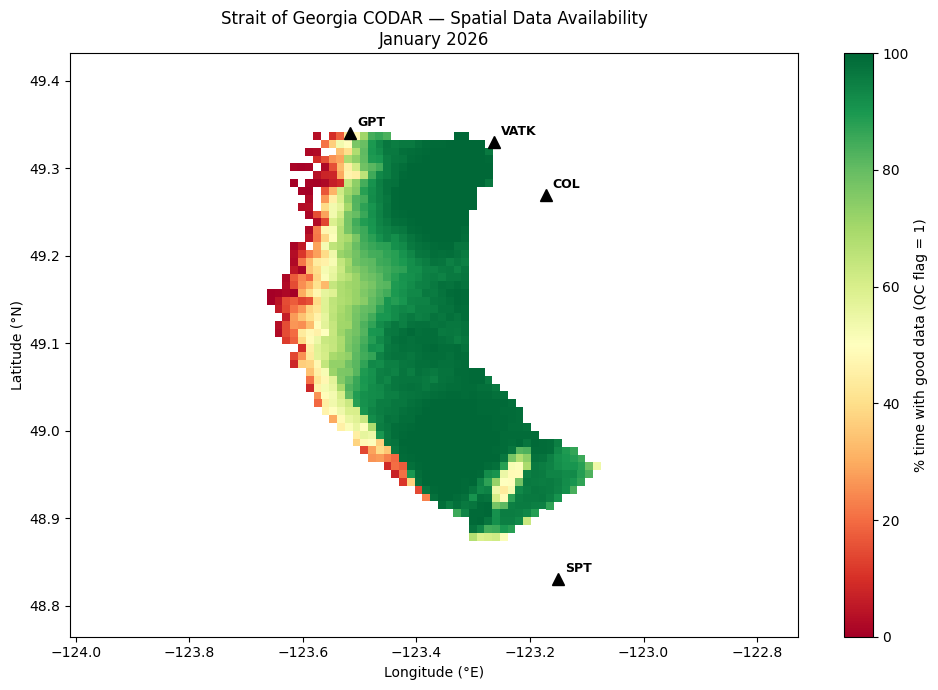

Saved to figures/spatial_availability_jan2026.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# % of time each grid point has good data
good_frac = (ds_onc.quality_flag == 1).mean(dim="time") * 100  # (y, x)

# Mask land points (where data is always NaN)
good_frac_masked = good_frac.where(good_frac > 0)

fig, ax = plt.subplots(figsize=(10, 7))

pcm = ax.pcolormesh(
    ds_onc.lon.values,
    ds_onc.lat.values,
    good_frac_masked.values,
    cmap="RdYlGn",
    vmin=0, vmax=100,
    shading="auto"
)

cbar = fig.colorbar(pcm, ax=ax, label="% time with good data (QC flag = 1)")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Strait of Georgia CODAR — Spatial Data Availability\nJanuary 2026")

# Mark the 4 radar sites
sites = {
    "VATK": (-123.264, 49.330),
    "COL":  (-123.172, 49.270),
    "GPT":  (-123.517, 49.340),
    "SPT":  (-123.150, 48.830),
}
for name, (lon, lat) in sites.items():
    ax.plot(lon, lat, "k^", markersize=8, zorder=5)
    ax.annotate(name, (lon, lat), textcoords="offset points",
                xytext=(5, 5), fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/spatial_availability_jan2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/spatial_availability_jan2026.png")

In [8]:
import xarray as xr
import glob
import os

# See what's downloaded
files = sorted(glob.glob(r"C:\Users\polinae\Documents\sog-hfradar\data\raw\onc\*.nc"))
for f in files:
    size = os.path.getsize(f) / 1e6
    print(f"{os.path.basename(f):50s}  {size:.1f} MB")

sog_hfradar_2024_Q2.nc                              114.8 MB
sog_hfradar_2024_Q3.nc                              110.2 MB
sog_hfradar_2025_H1.nc                              111.3 MB
sog_hfradar_2025_Q3b.nc                             65.1 MB
sog_hfradar_2025_Q4.nc                              114.5 MB


In [12]:
ds_all = xr.open_mfdataset(
    files,
    combine="by_coords"
)
print(ds_all)
print(f"\nTime coverage: {str(ds_all.time.values[0])[:16]} → {str(ds_all.time.values[-1])[:16]}")
print(f"Total timesteps: {ds_all.dims['time']}")

ImportError: chunk manager 'dask' is not available. Please make sure 'dask' is installed and importable.